## Import Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warning handling
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

## Dataset Loading

In [4]:
df = pd.read_csv('data/survey.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## Dataset Shape

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1259
Number of columns: 27


In [7]:
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:44:51,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981952,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


## Check Duplicate Values

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Check Missing Values

In [12]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

comments          1095
state              515
work_interfere     264
self_employed       18
dtype: int64

## Missing Value Percentage

In [13]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage
state,515,40.91
self_employed,18,1.43
work_interfere,264,20.97
comments,1095,86.97


## Data Cleaning

In [14]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]

In [15]:
df['Age'].describe()

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64

## Clean Gender

In [16]:
df['Gender'].value_counts()

Gender
Male                                              612
male                                              204
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Female                                              2
Cis Male                                            2
Man                                                 2
Female (trans)                                      2
Malr                                                1
Trans woman                                         1
male leaning androgynous                            1
Cis Man              

In [17]:
def clean_gender(gender):
    
    gender = str(gender).strip().lower()
    
    male_values = [
        'male', 'm', 'man', 'cis male',
        'male-ish', 'maile', 'mal',
        'male (cis)', 'make'
    ]
    
    female_values = [
        'female', 'f', 'woman',
        'cis female', 'femake',
        'female (cis)'
    ]
    
    if gender in male_values:
        return 'Male'
    
    elif gender in female_values:
        return 'Female'
    
    else:
        return 'Other'


df['Gender_Clean'] = df['Gender'].apply(clean_gender)

In [18]:
df['Gender_Clean'].value_counts()

Gender_Clean
Male      982
Female    245
Other      24
Name: count, dtype: int64

## Handle Self-Employed Missing Values

In [19]:
df['self_employed'].value_counts(dropna=False)

self_employed
No     1091
Yes     142
NaN      18
Name: count, dtype: int64

In [20]:
df['self_employed'].fillna(
    df['self_employed'].mode()[0],
    inplace=True
)

## Handle Work Interference

In [21]:
df['work_interfere'].fillna(
    'Not Applicable',
    inplace=True
)

In [22]:
df['work_interfere'].value_counts()

work_interfere
Sometimes         464
Not Applicable    262
Never             212
Rarely            173
Often             140
Name: count, dtype: int64

## State and Comments

In [23]:
df.drop(columns=['comments'], inplace=True)

In [24]:
df['state'].fillna('Not Applicable', inplace=True)

## Create Age Groups

In [25]:
bins = [18, 25, 35, 45, 55, 65, 80]

labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '66+'
]

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [26]:
df['Age_Group'].value_counts().sort_index()

Age_Group
18-25    217
26-35    701
36-45    277
46-55     42
56-65     13
66+        1
Name: count, dtype: int64

## Final Cleaning Check

In [27]:
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

(1251, 28)

Missing Values:
Timestamp                    0
Age                          0
Gender                       0
Country                      0
state                        0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
Gender_Clean                 0
Age_Group                    0
dtype: int64

Duplicate Rows:
0


## EDA – Chart 1: Treatment Distribution

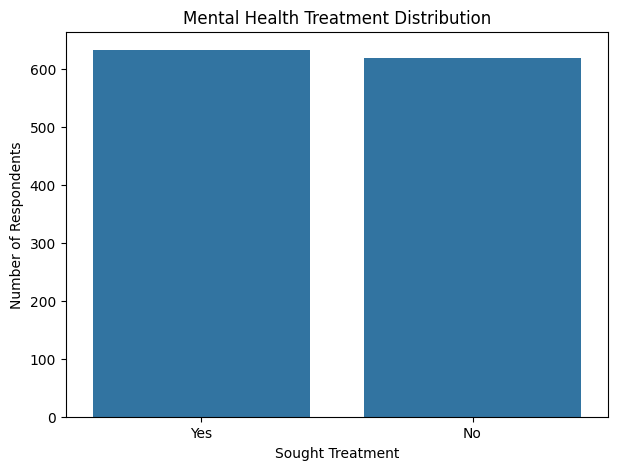

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='treatment'
)

plt.title('Mental Health Treatment Distribution')
plt.xlabel('Sought Treatment')
plt.ylabel('Number of Respondents')

plt.show()

## Chart 2 — Family History

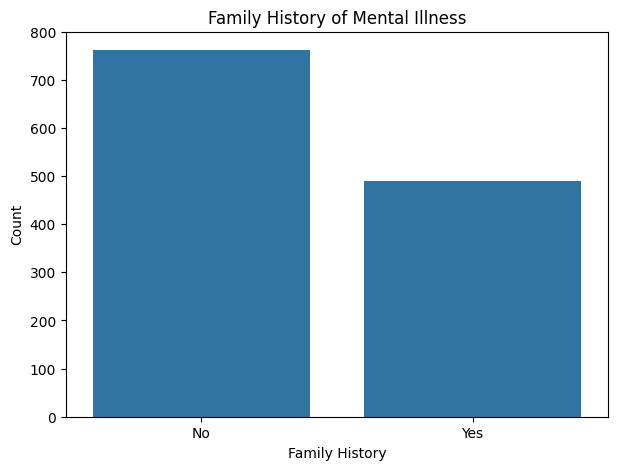

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='family_history'
)

plt.title('Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Count')

plt.show()

## Chart 3 — Treatment vs Family History

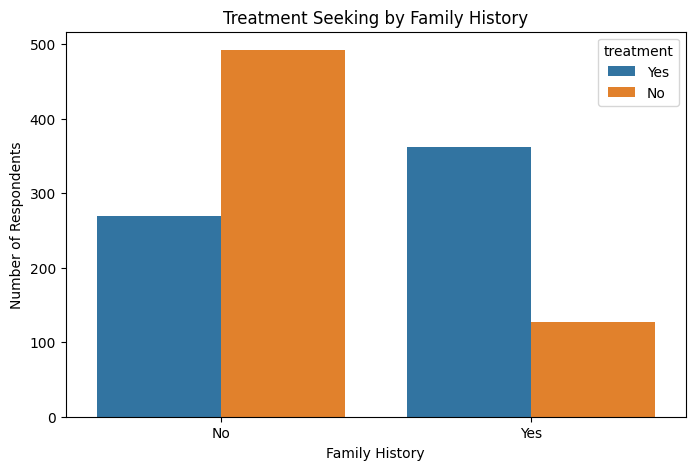

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='family_history',
    hue='treatment'
)

plt.title('Treatment Seeking by Family History')
plt.xlabel('Family History')
plt.ylabel('Number of Respondents')

plt.show()

In [32]:
family_treatment = pd.crosstab(
    df['family_history'],
    df['treatment'],
    normalize='index'
) * 100

family_treatment.round(2)

treatment,No,Yes
family_history,,
No,64.57,35.43
Yes,25.97,74.03


## Chart 4 — Work Interference

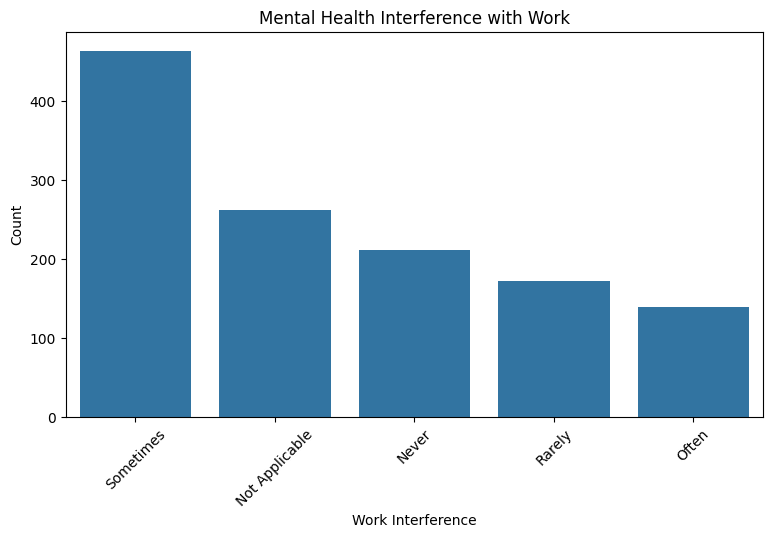

In [33]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='work_interfere',
    order=df['work_interfere'].value_counts().index
)

plt.title('Mental Health Interference with Work')
plt.xlabel('Work Interference')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

## Chart 5 — Work Interference vs Treatment

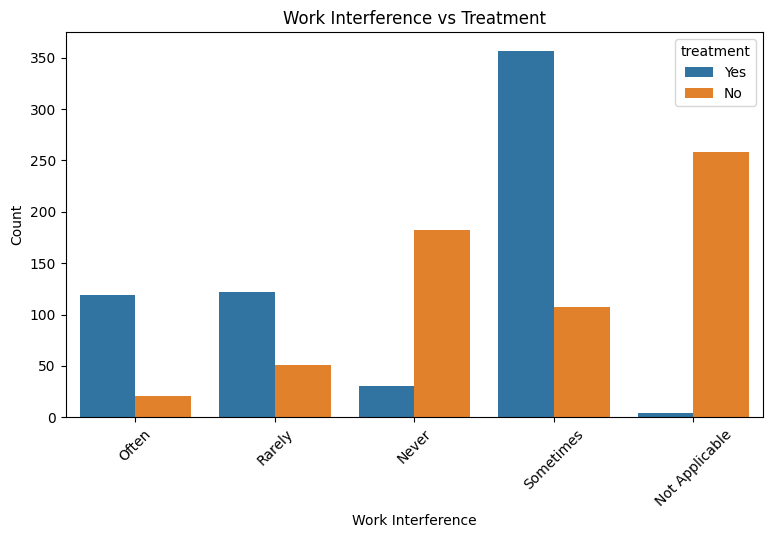

In [34]:

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='work_interfere',
    hue='treatment'
)

plt.title('Work Interference vs Treatment')
plt.xlabel('Work Interference')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

## Chart 6 — Mental Health Benefits

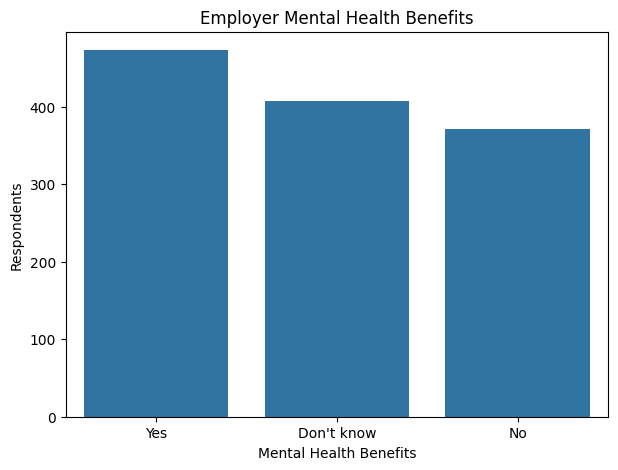

In [35]:

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='benefits'
)

plt.title('Employer Mental Health Benefits')
plt.xlabel('Mental Health Benefits')
plt.ylabel('Respondents')

plt.show()

## Chart 7 — Benefits vs Treatment

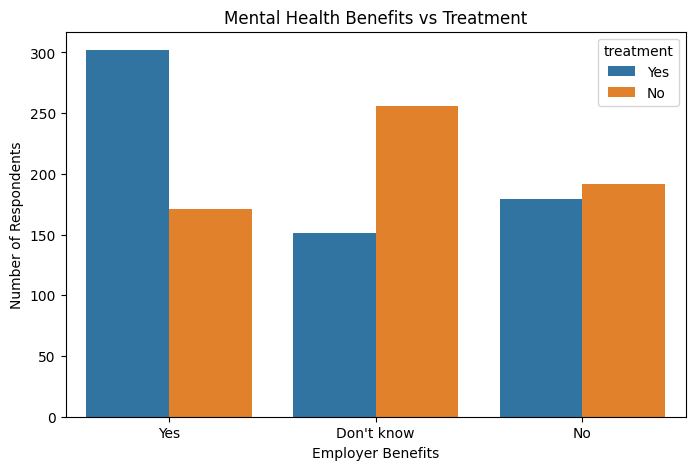

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='benefits',
    hue='treatment'
)

plt.title('Mental Health Benefits vs Treatment')
plt.xlabel('Employer Benefits')
plt.ylabel('Number of Respondents')

plt.show()

## Chart 8 — Care Options

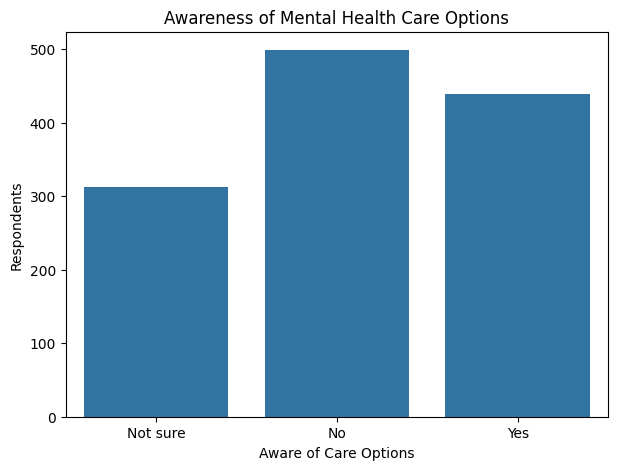

In [37]:

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='care_options'
)

plt.title('Awareness of Mental Health Care Options')
plt.xlabel('Aware of Care Options')
plt.ylabel('Respondents')

plt.show()

## Chart 9 — Wellness Program

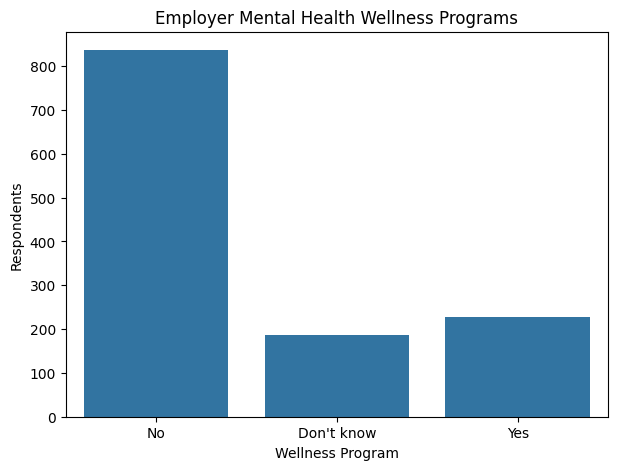

In [38]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='wellness_program'
)

plt.title('Employer Mental Health Wellness Programs')
plt.xlabel('Wellness Program')
plt.ylabel('Respondents')

plt.show()

## Chart 10 — Gender vs Treatment

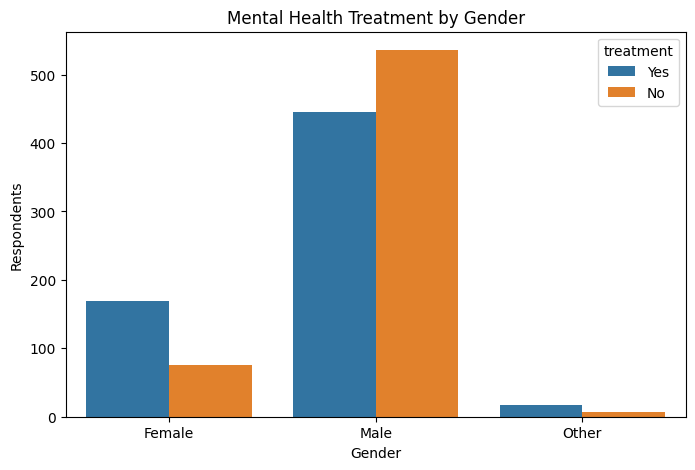

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Gender_Clean',
    hue='treatment'
)

plt.title('Mental Health Treatment by Gender')
plt.xlabel('Gender')
plt.ylabel('Respondents')

plt.show()

## Chart 11 — Age Distribution

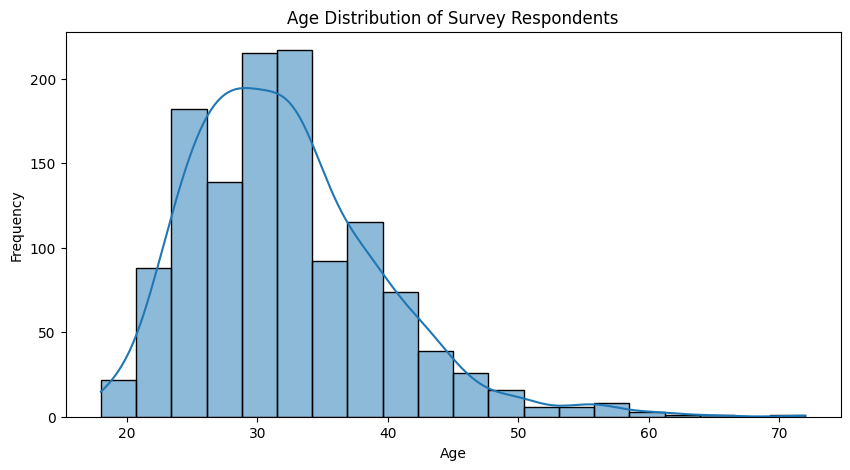

In [40]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title('Age Distribution of Survey Respondents')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

## Chart 12 — Age Group vs Treatment

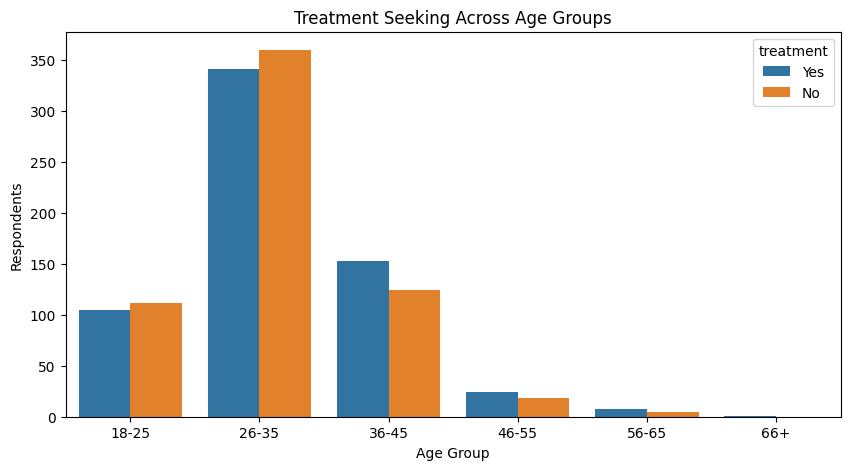

In [41]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Age_Group',
    hue='treatment'
)

plt.title('Treatment Seeking Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Respondents')

plt.show()

## Chart 13 — Company Size

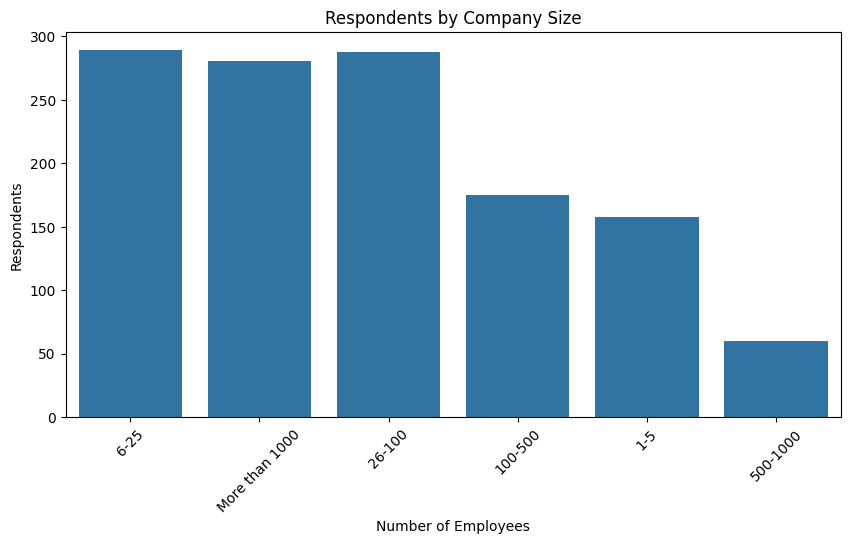

In [42]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='no_employees'
)

plt.title('Respondents by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Respondents')

plt.xticks(rotation=45)

plt.show()

## Chart 14 — Supervisor Discussion

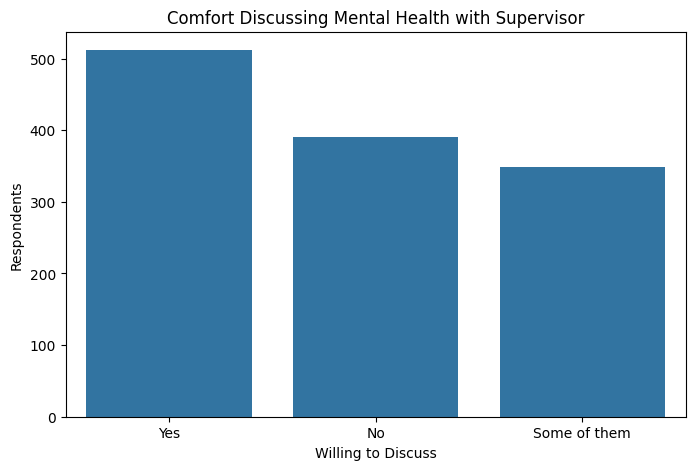

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='supervisor'
)

plt.title('Comfort Discussing Mental Health with Supervisor')
plt.xlabel('Willing to Discuss')
plt.ylabel('Respondents')

plt.show()

## Chart 15 — Mental Health vs Physical Health

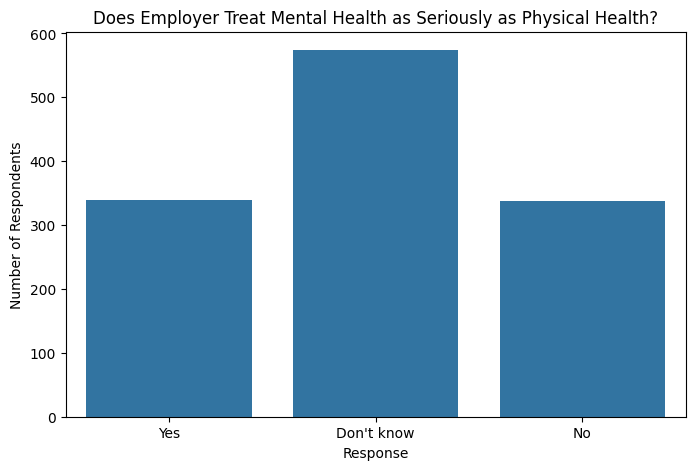

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='mental_vs_physical'
)

plt.title(
    'Does Employer Treat Mental Health '
    'as Seriously as Physical Health?'
)

plt.xlabel('Response')
plt.ylabel('Number of Respondents')

plt.show()

## Country Analysis

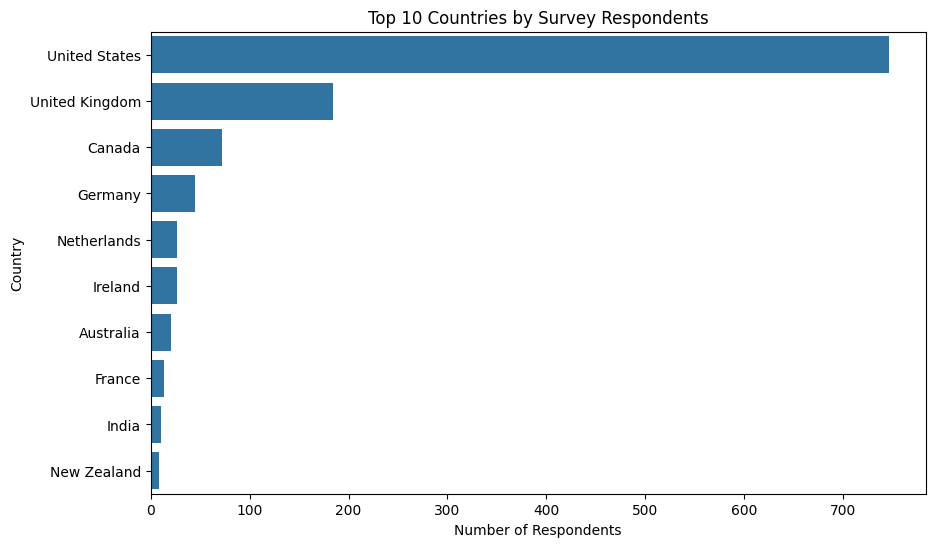

In [45]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries by Survey Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

plt.show()

## Country vs Treatment

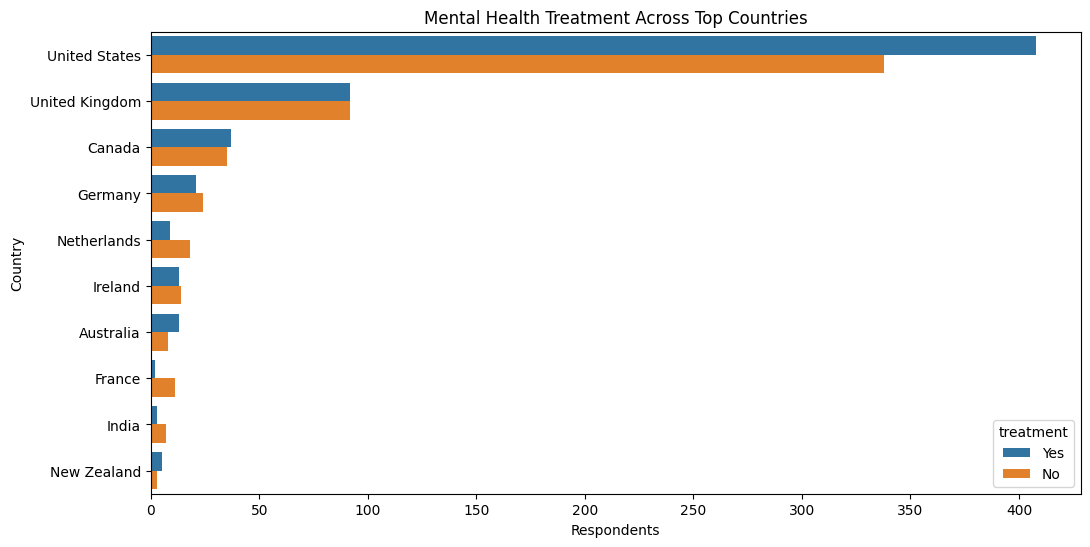

In [46]:
top_country_names = df['Country'].value_counts().head(10).index

country_df = df[
    df['Country'].isin(top_country_names)
]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=country_df,
    y='Country',
    hue='treatment',
    order=top_country_names
)

plt.title('Mental Health Treatment Across Top Countries')
plt.xlabel('Respondents')
plt.ylabel('Country')

plt.show()

## Important Summary Table

In [47]:
def percentage_table(column):
    
    table = df[column].value_counts(
        normalize=True
    ).mul(100).round(2)
    
    return table


print("Treatment")
print(percentage_table('treatment'))

print("\nFamily History")
print(percentage_table('family_history'))

print("\nBenefits")
print(percentage_table('benefits'))

print("\nCare Options")
print(percentage_table('care_options'))

print("\nWellness Program")
print(percentage_table('wellness_program'))

Treatment
treatment
Yes    50.52
No     49.48
Name: proportion, dtype: float64

Family History
family_history
No     60.91
Yes    39.09
Name: proportion, dtype: float64

Benefits
benefits
Yes           37.81
Don't know    32.53
No            29.66
Name: proportion, dtype: float64

Care Options
care_options
No          39.89
Yes         35.09
Not sure    25.02
Name: proportion, dtype: float64

Wellness Program
wellness_program
No            66.91
Yes           18.15
Don't know    14.95
Name: proportion, dtype: float64


## Treatment Rate Function

In [48]:
def treatment_rate(column):
    
    result = pd.crosstab(
        df[column],
        df['treatment'],
        normalize='index'
    ) * 100
    
    return result.round(2)

In [49]:
treatment_rate('family_history')

treatment,No,Yes
family_history,,
No,64.57,35.43
Yes,25.97,74.03


In [50]:
treatment_rate('benefits')

treatment,No,Yes
benefits,,
Don't know,62.90,37.10
No,51.75,48.25
Yes,36.15,63.85


In [51]:
treatment_rate('care_options')

treatment,No,Yes
care_options,,
No,58.72,41.28
Not sure,60.70,39.30
Yes,30.98,69.02


In [52]:
treatment_rate('care_options')

treatment,No,Yes
care_options,,
No,58.72,41.28
Not sure,60.70,39.30
Yes,30.98,69.02


In [53]:
treatment_rate('work_interfere')

treatment,No,Yes
work_interfere,,
Never,85.85,14.15
Not Applicable,98.47,1.53
Often,15.00,85.00
Rarely,29.48,70.52
Sometimes,23.06,76.94


In [54]:
treatment_rate('Gender_Clean')

treatment,No,Yes
Gender_Clean,,
Female,31.02,68.98
Male,54.58,45.42
Other,29.17,70.83


## Save Cleaned Dataset

In [55]:
df.to_csv(
    'cleaned_mental_health_survey.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
